In [ ]:
# Had to install 
# Had to install minoconda (Windows): https://www.anaconda.com/download/success
# Had to install Microsoft Visual Code, check Desktop development with C++ in install page: https://visualstudio.microsoft.com/visual-cpp-build-tools/
# Had to install Python extension in VSCodium

# Had to run in Anaconda prompt: 
    # conda create -n rcbplates python=3.11 -y
    # conda activate rcbplates
    # conda install -c conda-forge astropy photutils matplotlib numpy scipy pillow pycairo cairo pkg-config -y
    # pip install daschlab

# Then, in VSCodium:
    # Ctrl + Shift + P -> Python: Select Interpreter -> Python 3.11 (rcbplates)


In [12]:
pip install daschlab astropy photutils matplotlib numpy scipy pillow pycairo cairo pkg-config

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement cairo (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\dapur\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for cairo


In [20]:
from daschlab import open_session

sess = open_session("../data/raw/v854_cen_dasch")
sess.select_target("V854 Cen")
sess.select_refcat("apass")

In [21]:
exposures = sess.exposures()

In [22]:
exposures
exposures.colnames
exposures[:5]
cutout = sess.cutout(0)
cutout

'cutouts/00000_b03435m0s0.fits'

..\data\raw\v854_cen_dasch\cutouts\00000_b03435m0s0.fits
True


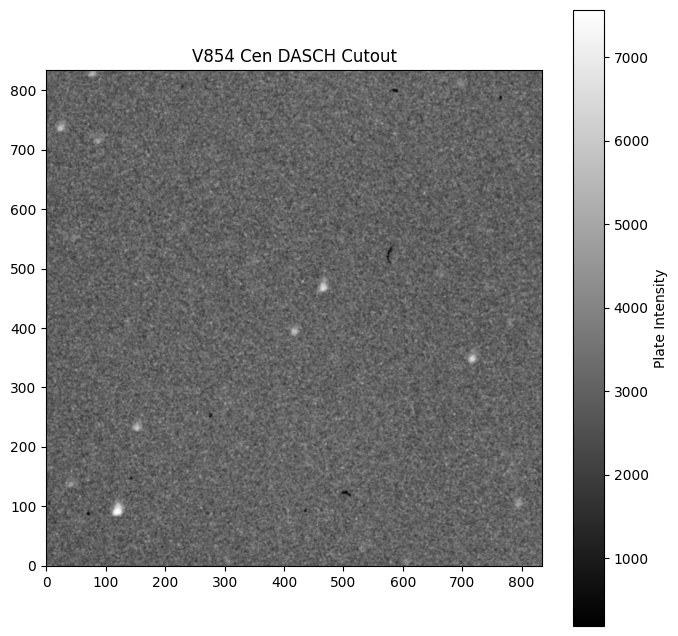

In [23]:
from pathlib import Path
from astropy.io import fits
import matplotlib.pyplot as plt

session_dir = Path("../data/raw/v854_cen_dasch")
cutout_path = session_dir / cutout

print(cutout_path)
print(cutout_path.exists())

data = fits.getdata(cutout_path)

plt.figure(figsize=(8, 8))
plt.imshow(data, origin="lower", cmap="gray")
plt.colorbar(label="Plate Intensity")
plt.title("V854 Cen DASCH Cutout")
plt.show()

In [24]:
# Problems start here; detection region incorrect.

from photutils.detection import DAOStarFinder
from astropy.stats import sigma_clipped_stats
import numpy as np

# Invert plate so dark stars become bright
image = np.nanmedian(data) - data

mean, median, std = sigma_clipped_stats(image, sigma=3.0)

daofind = DAOStarFinder(
    fwhm=4.0,
    threshold=7.0 * std
)

sources = daofind(image - median)

print(sources)
print("Detected sources:", 0 if sources is None else len(sources))

ModuleNotFoundError: No module named 'photutils'

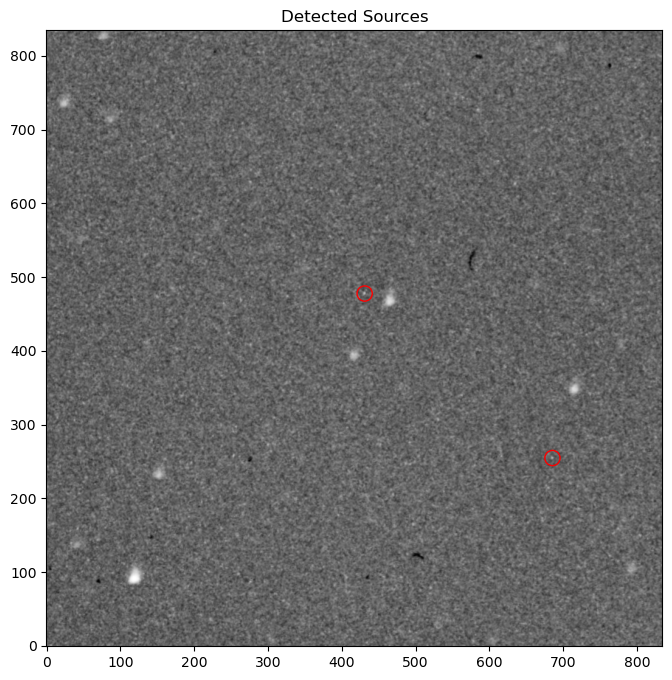

In [15]:
plt.figure(figsize=(8,8))
plt.imshow(data, origin="lower", cmap="gray")

plt.scatter(
    sources["xcentroid"],
    sources["ycentroid"],
    s=120,
    facecolors="none",
    edgecolors="red"
)

plt.title("Detected Sources")
plt.show()

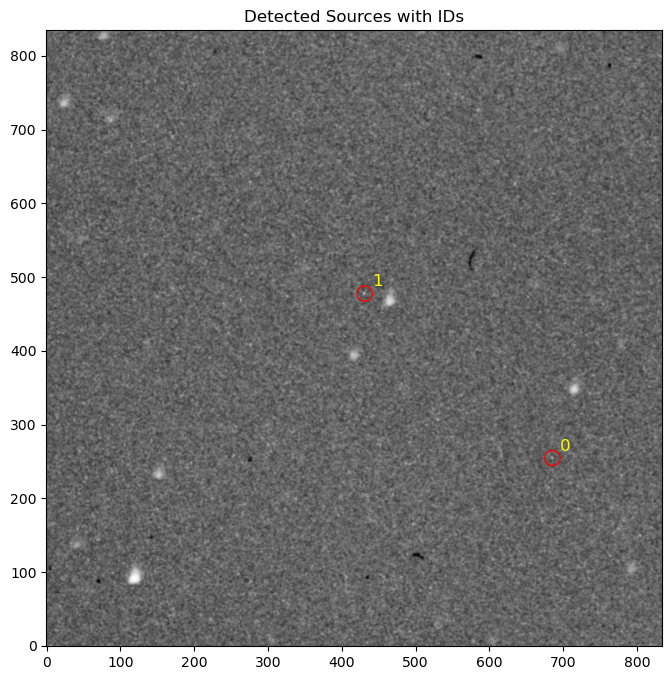

In [16]:
plt.figure(figsize=(8,8))
plt.imshow(data, origin="lower", cmap="gray")

plt.scatter(
    sources["xcentroid"],
    sources["ycentroid"],
    s=120,
    facecolors="none",
    edgecolors="red"
)

for i in range(len(sources)):
    plt.text(
        sources["xcentroid"][i] + 10,
        sources["ycentroid"][i] + 10,
        str(i),
        color="yellow",
        fontsize=12
    )

plt.title("Detected Sources with IDs")
plt.show()

In [17]:
sources["id", "xcentroid", "ycentroid", "flux"]

import numpy as np

fluxes = np.array(sources["flux"])

inst_mag = -2.5 * np.log10(fluxes)

sources["inst_mag"] = inst_mag

sources["id", "flux", "inst_mag"]

id,flux,inst_mag
int64,float32,float32
1,19069.0,-10.700819
2,29601.0,-11.178266


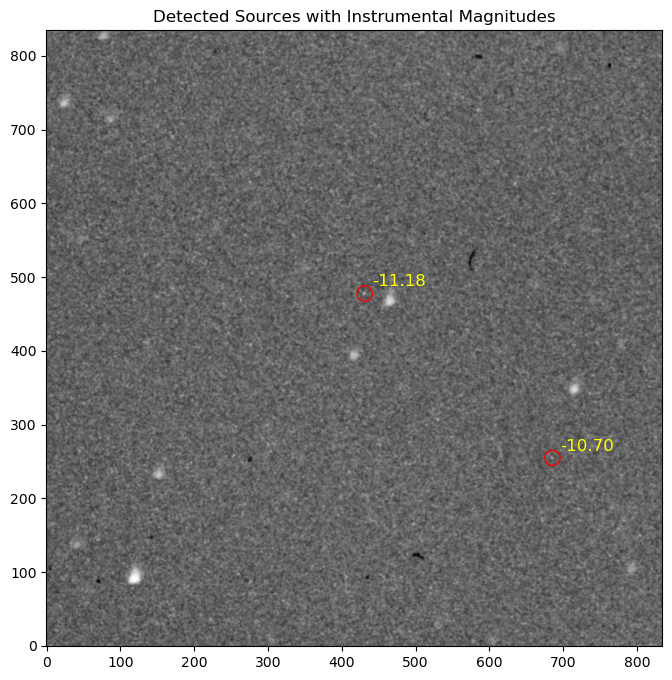

In [18]:
plt.figure(figsize=(8,8))
plt.imshow(data, origin="lower", cmap="gray")

plt.scatter(
    sources["xcentroid"],
    sources["ycentroid"],
    s=120,
    facecolors="none",
    edgecolors="red"
)

for i in range(len(sources)):
    plt.text(
        sources["xcentroid"][i] + 10,
        sources["ycentroid"][i] + 10,
        f'{sources["inst_mag"][i]:.2f}',
        color="yellow",
        fontsize=12
    )

plt.title("Detected Sources with Instrumental Magnitudes")
plt.show()

In [19]:
refcat = sess.refcat()
refcat[:10]
refcat.colnames

['ref_text',
 'ref_number',
 'gsc_bin_index',
 'pos',
 'dra',
 'ddec',
 'u_pm_ra_cosdec',
 'u_pm_dec',
 'stdmag',
 'color',
 'v_flag',
 'mag_flag',
 'class',
 'num_matches',
 'refcat',
 'local_id']

In [20]:
refcat["stdmag"][:20]
refcat["pos"][:5]
refcat[:5]

ref_text,ref_number,gsc_bin_index,pos,dra,ddec,u_pm_ra_cosdec,u_pm_dec,stdmag,color,v_flag,mag_flag,class,num_matches,refcat,local_id
,,,"deg,deg",arcsec,arcsec,mas / yr,mas / yr,mag,mag,,,,,,
str22,uint64,uint32,SkyCoord,float32,float32,float32,float32,float32,float32,uint16,uint16,uint16,uint32,str5,int64
APASS_J143449.4-393319,414344942393319,30684433,"218.705849,-39.55531",-0.01518273,-0.085284,1.9,1.9,8.62,0.48,1,0,0,962,apass,0
S233320119642,12233320119642,30684433,"218.70558099999997,-39.547698",0.72872776,-27.488483,0.0,0.0,18.82,0.69,1,0,3,5,apass,1
APASS_J143447.5-393259,414344752393259,30684433,"218.69800699999996,-39.549726",21.752232,-20.187683,0.0,0.0,14.52,0.52,0,0,0,16,apass,2
APASS_J143450.7-393252,414345072393252,30684434,"218.711306,-39.547771999999995",-15.162653,-27.222084,0.0,0.0,14.76,1.17,1,0,0,6,apass,3
APASS_J143449.7-393352,414344972393352,30666671,"218.706916,-39.564507",-2.9765892,33.023914,1.2,1.2,12.02,0.98,0,0,0,1516,apass,4


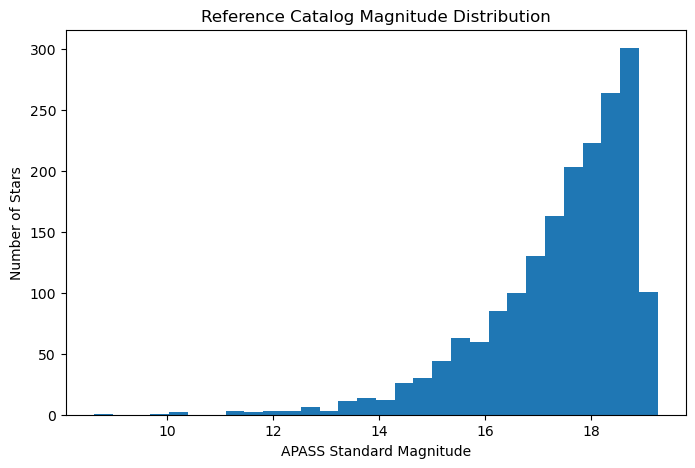

id,flux,inst_mag
int64,float32,float32
1,19069.0,-10.700819
2,29601.0,-11.178266


In [21]:
refcat["stdmag"][:50]
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(refcat["stdmag"], bins=30)

plt.xlabel("APASS Standard Magnitude")
plt.ylabel("Number of Stars")
plt.title("Reference Catalog Magnitude Distribution")

plt.show()
sources["id", "flux", "inst_mag"]

In [22]:
sources["xcentroid", "ycentroid", "flux", "inst_mag"]
import os

os.makedirs("../outputs/tables", exist_ok=True)

sources.write(
    "../outputs/tables/detected_sources.ecsv",
    overwrite=True
)

refcat.write(
    "../outputs/tables/reference_catalog.ecsv",
    overwrite=True
)